# Phase 3A-2A — Representative Possession / Boundary Review Pack

**REVIEW PACK READY — HUMAN LABELING PENDING.** Phase 3A-1 remains **DIAGNOSTIC / NOT A METHOD LOCK**. Phase 3A is not complete and segmentation is not locked.

Human review question: *At this point in the possession, does the attacking phase still look continuous, or has Leverkusen effectively reset before beginning another attack?*

This notebook supplies evidence, not an answer. No human labels/confidence are prefilled. The 28 cases reuse all 26 previous representatives and add two cases from the same bounded pool. All 25 requested categories have descriptive examples. Numeric criteria are **review sampling criteria**, not approved segmentation rules. Inspect ordinary and borderline observations as well as extremes.

Open the [static full review pack](../outputs/review/phase3a2_boundary_review.html) for every trace, summary, full timeline and selected spatial triptych. Annotate the [blank CSV worksheet](../outputs/diagnostics/phase3a2_boundary_review_sheet.csv) manually; keep candidate IDs unchanged. Use `review_order`, not the numerical case ID, for the intended reading order.

No data downloads or full-season recomputation occur in this notebook. Source revision: `533862946a73608c134d18b78226b6371ce7173c`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown
from leverkusen.sequences.boundary_review import HUMAN_COLUMNS, LABELS
from leverkusen.visualization.boundary_review import load_review_tables, SUMMARY_FIELDS

ROOT = Path.cwd() if (Path.cwd() / "config/project.yaml").exists() else Path.cwd().parent
tables = load_review_tables(ROOT)
manifest = tables["review_manifest"].sort_values("review_order")
worksheet = tables["boundary_review_sheet"]
timelines = tables["timelines"]


## Human label definitions

These are human calibration labels, **not model targets yet**. Supply a boundary index/time only if your judgment warrants it. An ambiguous or unavailable spatial state does not automatically require any particular label. Leave notes explaining football context, missing observations and competing interpretations.

Confidence: **1 = low; 2 = moderate; 3 = high**. Confidence is never calculated automatically.

In [2]:
display(pd.DataFrame(LABELS.items(), columns=["human label", "intended meaning"]))

,human label,intended meaning
0,CONTINUE,The attacking phase appears continuous despite...
1,POSSIBLE_RESET,"Evidence suggests the phase may have reset, bu..."
2,CLEAR_RESET,"Possession continues, but the prior attacking ..."
3,HARD_BOUNDARY,A football event/context provides a very stron...
4,AMBIGUOUS,Available event/spatial evidence does not supp...


## Evidence conventions

- Full context includes every event in the provider parent `(match_id, period, possession_id, possession_team_id=904)`, including opponents and administrative records. Provider possession does not certify uninterrupted Leverkusen control.
- `no_360_frame`, `linked_360_unsupported_semantics` and `validated_spatial_anchor` are separate from safe Pass/Carry vector status. Missing spatial state is never zero progression. Pressure actor coordinates are not ball location.
- Gold diamonds/crosses are explicit safe action starts/ends. **Lines connect ordered event observations for review; they are not tracked trajectories.** End vertices use action-start timestamps; endpoint arrival times are unavailable.
- Running peak/retreat in action rows describes the safe action path; no peak or coordinate is forward-filled into unsupported timeline rows. In candidate diagnostics `attacking_x` is the safe action **end**, `candidate_anchor_x` is a separate event/actor start reference, and `prior_peak_x` is the latest running-record maximum through that action (or the last available action reference at a non-action event). Never subtract a Pressure coordinate from a ball-path peak.
- Candidate `time_to_recovery` / `events_to_recovery` start at the candidate action-start reference, whereas Phase 3A-1 excursion recovery spans start at the record-peak reference. Recovery is first later safe vertex at/above that peak in the same parent; absence is censored, not evidence of failure. `largest_recent_negative_dx` covers the last three safe actions including the candidate. Run lengths are measured in the safe-action subsequence; other full-stream events can intervene.
- Each candidate has at most three prior and three subsequent **actual events**, never interpolated samples. Before/after snapshots are strictly nearest validated anchors inside the same provider parent. The candidate slot is exact; unavailable/unsupported states stay empty.
- Geometry uses locked native Phase 2A values, all six subset/keeper variants and Phase 2B support/status fields. Additional centroid coordinates use locked Phase 2C normalization. Outfield geometry is primary; observed hull footprint is secondary. D-primary, OOB-B, counts, coverage, actor, keeper, OOB and coincidence metadata accompany every displayed state. These are individual-state observations, not adjusted/common-support comparisons or boundary scores.
- Restart context is literal: Corner, Free Kick, Throw-in, Goal Kick, Kick Off. Corner at x=120 is retained. Shot outcomes, goals, xG and attacking success do not select cases or candidates.

## Review manifest and category coverage

Category flags describe why a case was sampled; they are not answers to the review question. Coverage overlaps. The 100-possession pool contains the 26 previous representatives plus all Leverkusen possessions in the earliest representative match; no new full-season analysis was run.

In [3]:
display(manifest[["review_order", "case_id", "review_group", "match_id", "period", "possession_id", "candidate_count", "pitch_panel_available"]])
display(tables["category_coverage"][["category", "review_sampling_criterion", "pool_count", "selected_count", "case_ids"]])

,review_order,case_id,review_group,match_id,period,possession_id,candidate_count,pitch_panel_available
0,1,C01,01_forward_contrasts,3895052,1,46,0,False
1,2,C02,01_forward_contrasts,3895060,2,172,2,True
2,3,C03,01_forward_contrasts,3895153,2,115,4,True
3,4,C04,02_single_action_retreat,3895052,1,12,8,True
4,5,C07,02_single_action_retreat,3895060,1,36,10,True
5,6,C13,03_multi_action_retreat,3895052,1,17,8,True
6,7,C14,03_multi_action_retreat,3895052,2,120,9,True
7,8,C21,04_recovery,3895052,1,15,2,True
8,9,C22,04_recovery,3895052,1,19,7,False
9,10,C23,04_recovery,3895052,1,23,2,False


,category,review_sampling_criterion,pool_count,selected_count,case_ids
0,nearly_monotonic,>=2 positive actions; full safe path maximum r...,17,2,C01;C03
1,one_small_backward,one negative action <=5; cumulative forward >=30,7,2,C02;C03
2,large_single_backward,maximum single backward action >=20,16,9,C04;C05;C06;C07;C08;C09;C10;C11;C12
3,single_without_extended_run,single backward >=20; longest strict negative ...,2,1,C06
4,gradual_multi_action,strict negative run >=3; cumulative backward >...,19,6,C13;C14;C15;C16;C17;C18
5,high_backward_without_large_action,cumulative backward >=40; largest single backw...,11,6,C13;C14;C15;C16;C17;C18
6,immediate_observed_recovery,observed record-peak recovery span <=3 seconds,33,12,C03;C04;C07;C08;C13;C14;C15;C17;C21;C23;C24;C25
7,delayed_observed_recovery,observed record-peak recovery span >15 seconds,14,10,C04;C07;C08;C10;C13;C15;C16;C17;C18;C25
8,unrecovered_observation,censored record-peak excursion; no assertion a...,39,13,C02;C06;C09;C10;C11;C12;C14;C15;C16;C17;C18;C1...
9,retreat_then_renewed_progression,observed excursion followed by a higher safe v...,52,18,C03;C04;C05;C06;C07;C08;C10;C13;C14;C15;C16;C1...


## Inspect any case

Change `CASE_ID` below and rerun the call. The helper shows the compact possession summary, attacking-x trace, available snapshot triptychs, candidate diagnostics, complete timeline and bounded candidate context. The static pack also contains every case. The worksheet remains a separate manual annotation artifact.

### C01 — 01_forward_contrasts

nearly_monotonic;short_fast

,value
possession_duration_seconds,6.963
total_event_count,8
validated_spatial_anchor_count,3
safe_action_count,3
first_safe_action_x,41.0
max_attacking_x_reached,74.5
last_safe_action_x,74.5
net_x_progression,33.5
cumulative_forward_x,33.5
cumulative_backward_x,-0.0


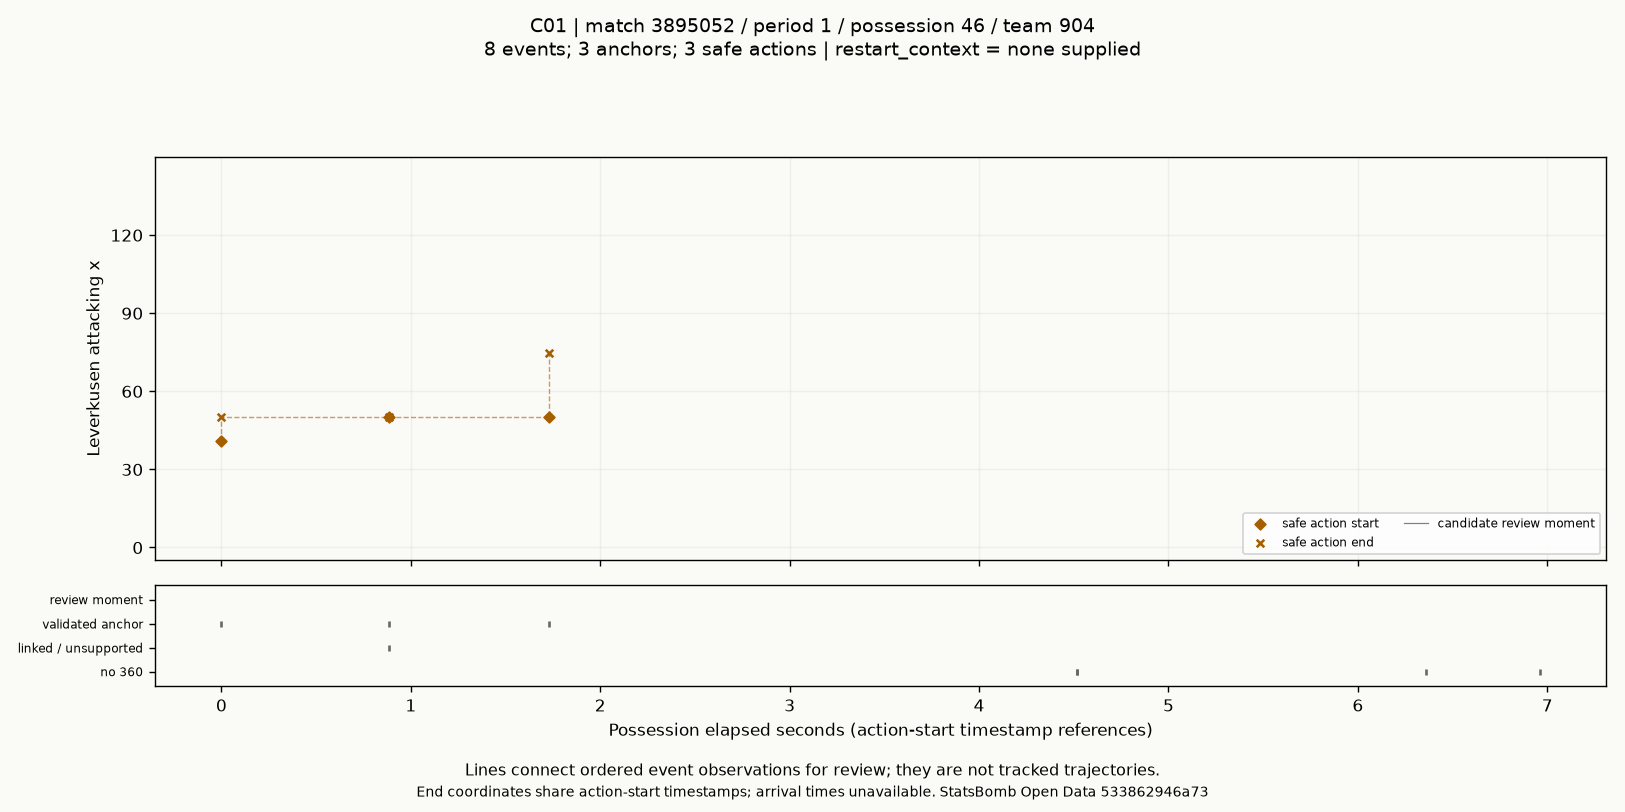

**Candidate review moments (all human fields initially blank)**

,case_id,match_id,period,possession_id,possession_team_id,candidate_id,candidate_event_index,candidate_elapsed_seconds,candidate_event_type,candidate_event_team,...,after_event_index,before_spatial_state_available,candidate_spatial_state_available,after_spatial_state_available,review_label,review_boundary_event_index,review_boundary_time,review_confidence,review_notes,statsbomb_revision


**Complete ordered event timeline**

,match_id,period,possession_id,possession_team_id,event_index,timestamp,event_type,event_team_id,linked_360,semantics_status,validated_anchor,is_shot,period_seconds,event_position,event_id,safe_action,action_candidate,explicit_vector_available,action_status,anchor_x,anchor_y,start_x_raw,start_y_raw,end_x_raw,end_y_raw,start_x,start_y,end_x,end_y,delta_x,delta_y,euclidean_displacement,elapsed_possession_time,player_name,event_team,provider_context,restart_context,spatial_state_status,prior_event_gap_seconds,running_peak_x,retreat_from_peak,positive_run_id,positive_run_length_so_far,negative_run_id,negative_run_length_so_far,nonpositive_run_id,nonpositive_run_length_so_far,case_id,statsbomb_revision
0,3895052,1,46,904,1168,00:27:15.443,Pass,904,True,validated_core_event_team_scope,True,False,1635.443,0,b0bc9ab4-ddfb-4f3e-8e3c-939a4a0501fe,True,True,True,safe_validated_frame_vector,41.0,59.6,41.0,59.6,50.0,64.0,41.0,59.6,50.0,64.0,9.0,4.4,10.017984,0.000,Odilon Kossonou,Bayer Leverkusen,counterpress:true;pass.type:Interception,,validated_spatial_anchor,NaN,50.0,0.0,positive_0072,1.0,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
1,3895052,1,46,904,1169,00:27:16.326,Ball Receipt*,904,True,unsupported_event_type,False,False,1636.326,1,3c44aadb-b77d-4744-91f1-ffe6f9211578,False,False,False,not_leverkusen_pass_carry,NaN,NaN,50.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.883,Jonas Hofmann,Bayer Leverkusen,,,linked_360_unsupported_semantics,0.883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
2,3895052,1,46,904,1170,00:27:16.326,Carry,904,True,validated_core_event_team_scope,True,False,1636.326,2,e4daacb7-1fd5-47f9-88b7-abc0128a09be,True,True,True,safe_validated_frame_vector,50.0,64.0,50.0,64.0,50.0,66.2,50.0,64.0,50.0,66.2,0.0,2.2,2.200000,0.883,Jonas Hofmann,Bayer Leverkusen,,,validated_spatial_anchor,0.000,50.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
3,3895052,1,46,904,1171,00:27:17.173,Pass,904,True,validated_core_event_team_scope,True,False,1637.173,3,f1b5ead2-be2b-4661-9777-45e8e35e0453,True,True,True,safe_validated_frame_vector,50.0,66.2,50.0,66.2,74.5,70.8,50.0,66.2,74.5,70.8,24.5,4.6,24.928097,1.730,Jonas Hofmann,Bayer Leverkusen,,,validated_spatial_anchor,0.847,74.5,0.0,positive_0073,1.0,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
4,3895052,1,46,904,1172,00:27:19.958,Ball Receipt*,904,False,no_360_frame,False,False,1639.958,4,6554952b-44df-4c64-b2ba-93e7db7f146d,False,False,False,not_leverkusen_pass_carry,NaN,NaN,74.5,70.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.515,Jeremie Frimpong,Bayer Leverkusen,,,no_360_frame,2.785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
5,3895052,1,46,904,1173,00:27:19.958,Carry,904,False,no_360_frame,False,False,1639.958,5,d7bcb5aa-5d70-4246-b6e2-89b029eb5001,False,True,True,unsupported_or_unlinked_frame,NaN,NaN,74.5,70.8,89.8,68.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.515,Jeremie Frimpong,Bayer Leverkusen,,,no_360_frame,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
6,3895052,1,46,904,1174,00:27:21.801,Pressure,182,False,no_360_frame,False,False,1641.801,6,8552610d-1000-43a6-a024-cfdd9002b26f,False,False,False,not_leverkusen_pass_carry,NaN,NaN,43.8,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.358,David Raum,RB Leipzig,,,no_360_frame,1.843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c
7,3895052,1,46,904,1175,00:27:22.406,Dribble,904,False,no_360_frame,False,False,1642.406,7,c4c3f6e3-bccf-4e9b-82c3-5d331b063d98,False,False,False,not_leverkusen_pass_carry,NaN,NaN,89.8,68.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.963,Jeremie Frimpong,Bayer Leverkusen,,,no_360_frame,0.605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C01,533862946a73608c134d18b78226b6371ce7173c


**Bounded candidate context: actual events only**

,match_id,period,possession_id,possession_team_id,event_index,timestamp,event_type,event_team_id,linked_360,semantics_status,...,positive_run_id,positive_run_length_so_far,negative_run_id,negative_run_length_so_far,nonpositive_run_id,nonpositive_run_length_so_far,case_id,candidate_id,context_event_offset,statsbomb_revision


In [4]:
def review_case(case_id):
    case = manifest.set_index("case_id").loc[case_id]
    display(Markdown(f"### {case_id} — {case.review_group}\n\n{case.selection_reason}"))
    display(case[SUMMARY_FIELDS].to_frame("value"))
    display(Image(filename=str(ROOT / case.figure_path)))
    slots = tables["spatial_slots"]
    for candidate_id in slots.loc[slots.case_id.eq(case_id), "candidate_id"].unique():
        display(Image(filename=str(ROOT / f"outputs/figures/phase3a2_{candidate_id}_spatial.png")))
    display(Markdown("**Candidate review moments (all human fields initially blank)**"))
    display(worksheet[worksheet.case_id.eq(case_id)])
    display(Markdown("**Complete ordered event timeline**"))
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(timelines[timelines.case_id.eq(case_id)])
    display(Markdown("**Bounded candidate context: actual events only**"))
    display(tables["candidate_context"].loc[lambda t: t.case_id.eq(case_id)])

CASE_ID = "C01"
review_case(CASE_ID)

## Forward-progression contrasts

C01 has a monotonic measured path and zero candidate moments. C02/C03 contain a small single backward action. These descriptions are not CONTINUE labels.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [5]:
display(manifest.loc[manifest.review_group.eq("01_forward_contrasts"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
0,C01,3895052,1,46,0,,nearly_monotonic;short_fast
1,C02,3895060,2,172,2,,one_small_backward;unrecovered_observation;opp...
2,C03,3895153,2,115,4,,nearly_monotonic;one_small_backward;immediate_...


## Single-action retreat examples

Compare the explicit backward vector with the cumulative path retreat. Gaps between safe actions are not measured movement.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [6]:
display(manifest.loc[manifest.review_group.eq("02_single_action_retreat"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
3,C04,3895052,1,12,8,,large_single_backward;immediate_observed_recov...
4,C07,3895060,1,36,10,,large_single_backward;immediate_observed_recov...


## Multi-action retreat examples

Inspect strict and non-positive runs alongside intervening full-context events. Several short negative actions are not automatically a reset.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [7]:
display(manifest.loc[manifest.review_group.eq("03_multi_action_retreat"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
5,C13,3895052,1,17,8,,gradual_multi_action;high_backward_without_lar...
6,C14,3895052,2,120,9,,gradual_multi_action;high_backward_without_lar...


## Recovery examples

Compare short and longer observed recovery references. See coverage table for recovery examples in other groups too; censored observations do not establish unrecovered football states.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [8]:
display(manifest.loc[manifest.review_group.eq("04_recovery"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
7,C21,3895052,1,15,2,,immediate_observed_recovery;retreat_then_renew...
8,C22,3895052,1,19,7,Goal Kick,retreat_then_renewed_progression;shot_context;...
9,C23,3895052,1,23,2,,immediate_observed_recovery;retreat_then_renew...
10,C24,3895052,2,92,5,Kick Off,immediate_observed_recovery;retreat_then_renew...


## Set-piece and Corner examples

Inspect C09 and C11 Corner-seeded x=120 paths; C12 has Corner snapshots and is grouped with Shot context. C05/C18/C25/C26 show Free Kick context; C06 shows Throw-in. Do not suppress retreat or classify episodes automatically.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [9]:
display(manifest.loc[manifest.review_group.eq("05_set_pieces"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
11,C05,3895052,2,174,8,Free Kick,large_single_backward;retreat_then_renewed_pro...
12,C06,3895060,1,23,7,Throw-in,large_single_backward;single_without_extended_...
13,C09,3895153,1,21,5,Corner,large_single_backward;unrecovered_observation;...
14,C11,3895210,1,15,7,Corner,large_single_backward;unrecovered_observation;...
15,C18,3895153,1,43,13,Free Kick,gradual_multi_action;high_backward_without_lar...
16,C25,3895060,1,64,11,Free Kick,immediate_observed_recovery;delayed_observed_r...
17,C26,3895052,2,126,2,Free Kick,free_kick_started;out_context;short_fast;oppon...


## Shot and later same-parent actions

C12 has Shot → Goal Keeper → Clearance → Leverkusen Pass/Carry. Its exact Shot frame is unsupported and remains unavailable in the spatial triptych. C15 has Block/Goal Keeper/Clearance followed by a Leverkusen Pass. C10 and C17 include longer opponent activity before later Leverkusen actions. Provider parent continuity does not prove uninterrupted control. No Shot is automatically an episode end.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [10]:
display(manifest.loc[manifest.review_group.eq("06_shot_context"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
18,C10,3895167,2,106,11,Throw-in,large_single_backward;delayed_observed_recover...
19,C12,3895292,2,109,9,Corner,large_single_backward;unrecovered_observation;...
20,C15,3895067,1,3,10,Free Kick,gradual_multi_action;high_backward_without_lar...
21,C17,3895121,2,83,12,,gradual_multi_action;high_backward_without_lar...


## Long and multi-peak possessions

C08/C16 exceed 120 seconds. Many other long cases appear under set pieces and Shot context; use category coverage to compare them. Duration includes context/stoppage time.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [11]:
display(manifest.loc[manifest.review_group.eq("07_long_complex"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
22,C08,3895067,2,102,12,,large_single_backward;immediate_observed_recov...
23,C16,3895086,1,23,11,,gradual_multi_action;high_backward_without_lar...


## Circulation, discontinuity and sparse evidence

C19 is an ordinary circulation sampling example; C20 has nonnegative action vectors but path retreat through coordinate jumps. C27/C28 are sparse-context contrasts. These cases have no preassigned AMBIGUOUS label.

Use `review_case("Cxx")` above or the static pack to inspect each listed case.

In [12]:
display(manifest.loc[manifest.review_group.eq("08_borderline_context"), ["case_id", "match_id", "period", "possession_id", "candidate_count", "restart_context", "selection_reason"]])

,case_id,match_id,period,possession_id,candidate_count,restart_context,selection_reason
24,C19,3895052,1,6,3,,unrecovered_observation;shot_context;circulati...
25,C20,3895052,1,9,1,,unrecovered_observation;advanced_origin_retrea...
26,C27,3895052,1,1,2,,sparse_anchors
27,C28,3895052,1,22,0,,sparse_anchors


## Blank human-review summary

The supplied sheet contains 181 candidate moments across 26 of the 28 cases; two cases deliberately have zero candidates. All five human fields are blank. Editing the CSV is a human Phase 3A-2B step. A full regeneration refuses to overwrite an annotated worksheet.

In [13]:
display(worksheet[HUMAN_COLUMNS].notna().sum().rename("nonblank supplied human fields"))
assert worksheet[HUMAN_COLUMNS].fillna("").eq("").all().all()
display(pd.Series({"possessions": len(manifest), "candidate moments": len(worksheet), "full-context events": len(timelines), "usable snapshot panels": int(tables["spatial_slots"].spatial_state_available.sum()), "snapshot slots": len(tables["spatial_slots"])}))

review_label                   0
review_boundary_event_index    0
review_boundary_time           0
review_confidence              0
review_notes                   0
Name: nonblank supplied human fields, dtype: int64

possessions                 28
candidate moments          181
full-context events       1960
usable snapshot panels      37
snapshot slots              51
dtype: int64

## After human Phase 3A-2B review

The next step is human labeling, with confidence and notes. Phase 3A-3 will consider segmentation calibration and a separate method lock **after labels are supplied**. It must assess disagreements, missing observations, restart/Shot context and sensitivity before proposing rules. No numeric review screen is approved for production, no final episodes or outcomes exist, and no ML, clustering or change-point method is fitted here.

Limits: purposive case coverage is not prevalence; source semantics remain restricted; 360 is partial; endpoint times and continuous ball/player trajectories are unavailable. Geometry only corroborates human interpretation. The original 2,888-parent / 86,025-event / 37,984-vector diagnostics remain unchanged.